In [ ]:
from scipy.stats import mannwhitneyu
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

My first step for my data analysis was to read in my new data and look at the first few rows to verify accuracy.

In [ ]:
df = pd.read_csv("data/processed/fiction_pagecounts_2016_2025.csv")

print(df.shape)
print(df.dtypes)
df.head()

(3895, 5)
key                       str
title                     str
author_name               str
first_publish_year      int64
page_count            float64
dtype: object


,key,title,author_name,first_publish_year,page_count
0,/works/OL17797130W,A Gentleman in Moscow,['Amor Towles'],2016,511.0
1,/works/OL20808172W,Punk 57,['Penelope Douglas'],2016,363.0
2,/works/OL17876096W,Scythe,['Neal Shusterman'],2016,449.0
3,/works/OL17625829W,Empire of Storms,['Sarah J. Maas'],2016,704.0
4,/works/OL17364743W,The Hidden Oracle,['Rick Riordan'],2016,384.0


I then grouped by year and used aggregate to compute the summary statistics for each year. I then reset the index and printed my results.

In [3]:
yearly_stats = df.groupby('first_publish_year')['page_count'].agg(
    median='median',
    mean='mean',
    std='std',
    count='count'
).reset_index()

print(yearly_stats)

   first_publish_year  median        mean         std  count
0                2016   352.0  352.546638  133.561712    461
1                2017   352.0  354.609071  121.042605    463
2                2018   352.0  352.738462  120.165908    455
3                2019   368.0  377.204641  120.152345    474
4                2020   352.0  364.038462  115.285265    468
5                2021   368.0  370.967672  105.875069    464
6                2022   368.0  374.168901  118.310876    373
7                2023   384.0  386.825342  122.501506    292
8                2024   380.0  373.078341  110.384255    217
9                2025   336.0  343.192982  128.584389    228


I decided to use mannwhitneyu to perform a Wilcoxon rank-sum test to see if the furst half of the decade had the same distribution as the last half of the decade. I did this by seperating the data by assigning the boolean value 'true' to if the book is from the first half of the decade and 'false' if it isn't. I then stored that data and repeated for books published in the second half of the decade. I then used mannwhitneyu to find the test statistic and p value for both groups and printed my results to check for accuracy. 

In [ ]:
early = df[df['first_publish_year'] <= 2020]['page_count']
recent = df[df['first_publish_year'] >= 2021]['page_count']

print("2016-2020 median:", early.median())
print("2021-2025 median:", recent.median())

stat, p = mannwhitneyu(early, recent)
print("Mann-Whitney p-value:", p)

2016-2020 median: 352.0
2021-2025 median: 368.0
Mann-Whitney p-value: 0.0009323424657554684


The first graph I decided to make using matplotlib is a line graph. This graph is a straightforward way to see the relative trend in book length over 10 years.

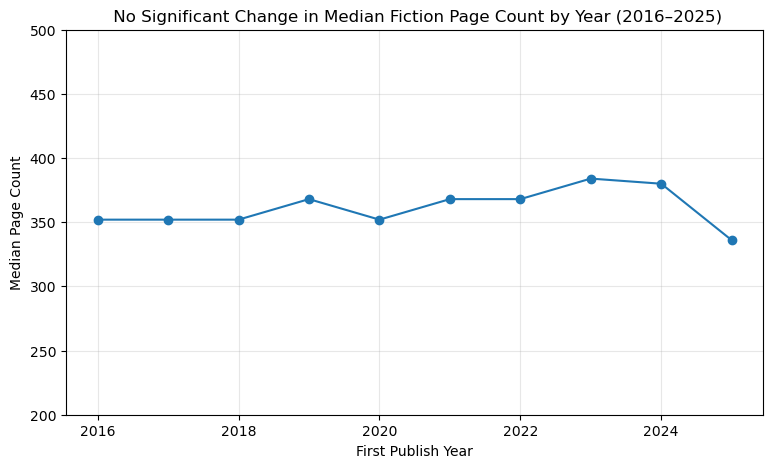

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(yearly_stats['first_publish_year'], yearly_stats['median'], marker='o')
plt.title(" No Significant Change in Median Fiction Page Count by Year (2016–2025)")
plt.xlabel("First Publish Year")
plt.ylabel("Median Page Count")
plt.ylim(200, 500)
plt.grid(alpha=0.3)
plt.show()

I then used matplotlib to look at the distribution of page length for each individual year.

<Figure size 1000x600 with 0 Axes>

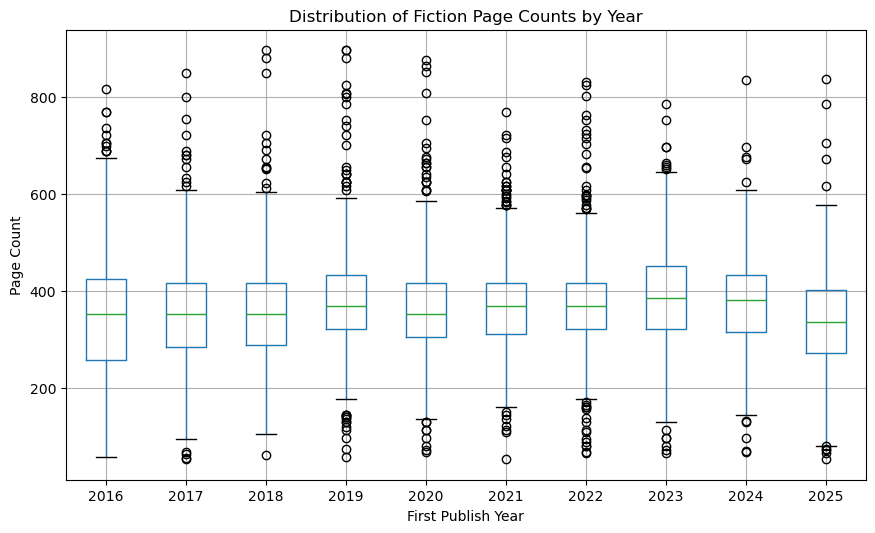

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.boxplot(column='page_count', by='first_publish_year', figsize=(10, 6))
plt.title("Distribution of Fiction Page Counts by Year")
plt.suptitle("")  
plt.xlabel("First Publish Year")
plt.ylabel("Page Count")
plt.show()

My final step was to use linregress, a tool I've learned at my home univeristy, to fit a linear regression to my data and compute the statistics of that line. This gave me a direct answer to my original question for this project. 

In [ ]:
result = linregress(yearly_stats['first_publish_year'], yearly_stats['median'])
print(f"Slope: {result.slope:.2f} pages/year")
print(f"R-squared: {result.rvalue**2:.3f}")
print(f"P-value: {result.pvalue:.4f}")

Slope: 1.38 pages/year
R-squared: 0.079
P-value: 0.4305
